In [2]:
pip install pandas numpy matplotlib openpyxl --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 37.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 36.5 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 43.4 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 43.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 39.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [matplotlib]1 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)

1. Data Acquisition and Cleaning

In [5]:
sheet_map = { 
    'Sheet 1': ('JNJ', 'Johnson & Johnson'),
    'Sheet 1 (2)': ('AMZN', 'Amazon.com Inc'),
    'Sheet 1 (3)': ('SPX', 'S&P 500 Index'),
    'Sheet 1 (4)': ('UBER', 'Uber Technologies Inc'),
    'Sheet 1 (5)': ('ORCL', 'Oracle Corporation'),
    'Sheet 1 (6)': ('CAT', 'Caterpillar Inc'),
    'Sheet 1 (7)': ('NFLX', 'Netflix Inc'),
    'Sheet 1 (8)': ('V', 'Visa Inc'),
    'Sheet 1 (9)': ('DIS', 'The Walt Disney Company'),
    'Sheet 1 (10)': ('KO', 'Coca Cola Co'),
}
ticker_order = ['JNJ', 'AMZN', 'SPX', 'UBER', 'ORCL', 'CAT', 'NFLX', 'V', 'DIS', 'KO']

xls = pd.ExcelFile('../excels/copiafondo.xlsx')
frames = []
for sheet, (ticker, name) in sheet_map.items():
    raw = pd.read_excel(xls, sheet_name=sheet, header=None)
    header_row = raw[raw[0] == 'Exchange Date'].index[0]
    d = pd.read_excel(xls, sheet_name=sheet, header=header_row)
    keep = [c for c in ['Exchange Date', 'Open', 'High', 'Low', 'Close', 'Volume'] if c in d.columns]
    d = d[keep].rename(columns={'Exchange Date': 'Date'})
    d['Ticker'] = ticker
    d['Company'] = name
    frames.append(d)

fondo = pd.concat(frames, ignore_index=True)
fondo['Date'] = pd.to_datetime(fondo['Date'])
fondo = fondo.sort_values(['Ticker', 'Date']).reset_index(drop=True)
fondo = fondo[['Ticker', 'Company', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
fondo['Volume'] = fondo['Volume'].astype(float)
fondo['Daily_Return'] = fondo.groupby('Ticker')['Close'].pct_change()
print(fondo.shape)
fondo.head()


(12560, 9)


,Ticker,Company,Date,Open,High,Low,Close,Volume,Daily_Return
0,AMZN,Amazon.com Inc,2021-09-10,175.09154,175.4225,173.145275,173.4575,47945380.0,NaN
1,AMZN,Amazon.com Inc,2021-09-13,174.14000,174.8980,171.900005,172.8585,51380440.0,-0.003453
2,AMZN,Amazon.com Inc,2021-09-14,173.77750,174.3403,171.885520,172.5000,38737940.0,-0.002074
3,AMZN,Amazon.com Inc,2021-09-15,172.12600,174.2710,170.100500,173.7895,59150740.0,0.007475
4,AMZN,Amazon.com Inc,2021-09-16,172.99800,174.6275,172.307160,174.4120,51671960.0,0.003582


In [8]:
print("Duplicate Ticker-Date rows:", fondo.duplicated(subset=['Ticker', 'Date']).sum())
print("\nMissing vales by column:")
print(fondo.isna().sum())
print("\nDate range:", fondo['Date'].min().date(), "to", fondo['Date'].max().date())

fondo.to_excel('fondo_clean.xlsx', sheet_name='fondo', index=False)

Duplicate Ticker-Date rows: 0

Missing vales by column:
Ticker             0
Company            0
Date               0
Open               0
High               0
Low                0
Close              0
Volume          1256
Daily_Return      10
dtype: int64

Date range: 2021-09-10 to 2026-09-11


Interpetation:

2. Identification of Dependent and Independent Variables

In [11]:
fondo['Volatility_20d'] = fondo.groupby('Ticker')['Daily_Return'].transform(lambda s: s.rolling(20).std())
fondo['SMA_20'] =fondo.groupby('Ticker')['Close'].transform(lambda s: s.rolling(20).mean())

spx_ret = fondo.loc[fondo['Ticker'] == 'SPX'].set_index('Date')['Daily_Return']
betas = {}
for t in ticker_order:
    if t == 'SPX':
        continue
    r = fondo.loc[fondo['Ticker'] == t].set_index('Date')['Daily_Return']
    joined = pd.concat([r, spx_ret], axis=1, keys=['stock', 'mkt']).dropna()
    betas[t] = round(np.cov(joined['stock'], joined['mkt'])[0,1] / np.var(joined['mkt']),2)

beta_table = pd.Series(betas, name='Beta_vs_SPX').sort_values(ascending=False)
beta_table

AMZN    1.51
UBER    1.36
ORCL    1.24
NFLX    1.22
CAT     1.07
DIS     1.01
V       0.81
KO      0.26
JNJ     0.16
Name: Beta_vs_SPX, dtype: float64

Interpetation:

3. Evaluation of Information Technologies
In the document but here's a summary:


4. Analysis of the Client’s Risk Profile
In the document but here's a summary:


5. Initial Data Visualization and Description

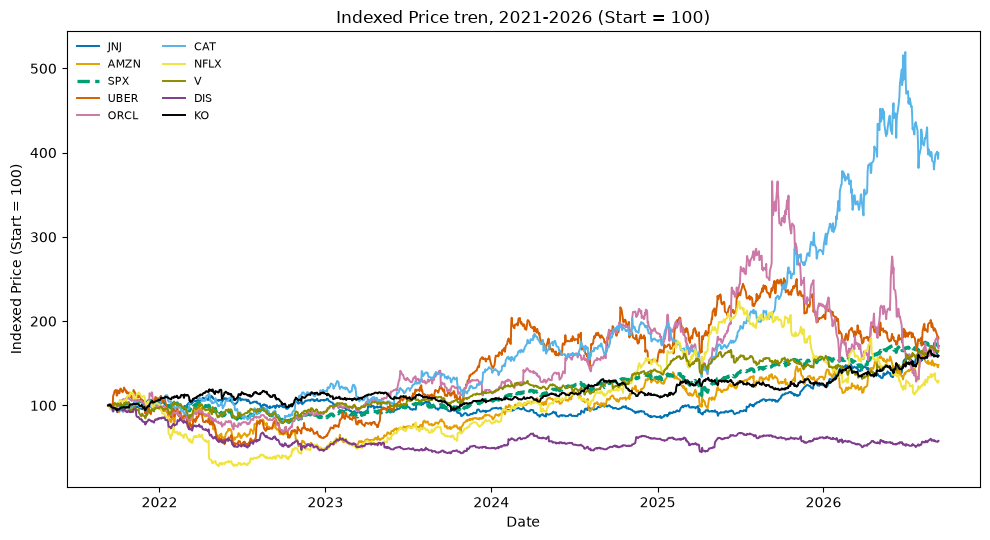

In [13]:
palette = ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7', '#56B4E9', '#F0E442', '#8C8C00', '#7F3C8D', '#000000']
color_map = dict(zip(ticker_order, palette))

fig, ax = plt.subplots(figsize=(10,5.5))
for t in ticker_order:
    sub = fondo[fondo['Ticker'] == t].sort_values('Date')
    idx = sub['Close'] / sub['Close'].iloc[0] * 100
    lw, ls = (2.4, '--') if t == 'SPX' else (1.4, '-')
    ax.plot(sub['Date'], idx, label=t, color=color_map[t],linewidth=lw, linestyle=ls)
ax.set_title('Indexed Price tren, 2021-2026 (Start = 100)')
ax.set_xlabel('Date'); ax.set_ylabel('Indexed Price (Start = 100)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', ncol=2, fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

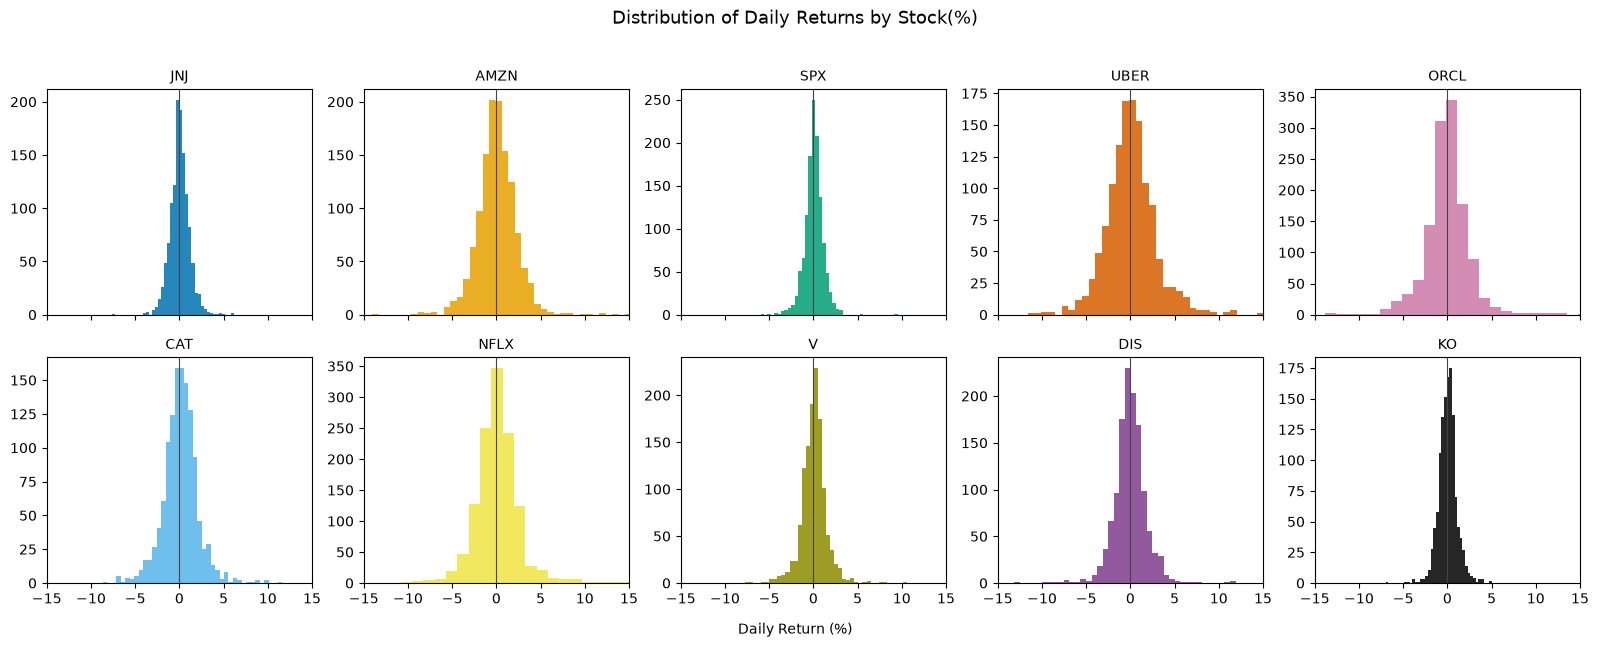

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharex=True)
for ax, t in zip(axes.flat, ticker_order):
    r = fondo.loc[fondo['Ticker'] == t, 'Daily_Return'].dropna() * 100
    ax.hist(r, bins=40, color=color_map[t], alpha=0.85)
    ax.axvline(0, color='#444444', linewidth=0.8)
    ax.set_title(t, fontsize=10)
    ax.set_xlim(-15, 15)
fig.suptitle('Distribution of Daily Returns by Stock(%)', y=1.02, fontsize=13)
fig.text(0.5, -0.02, 'Daily Return (%)', ha='center')
plt.tight_layout()
plt.show()

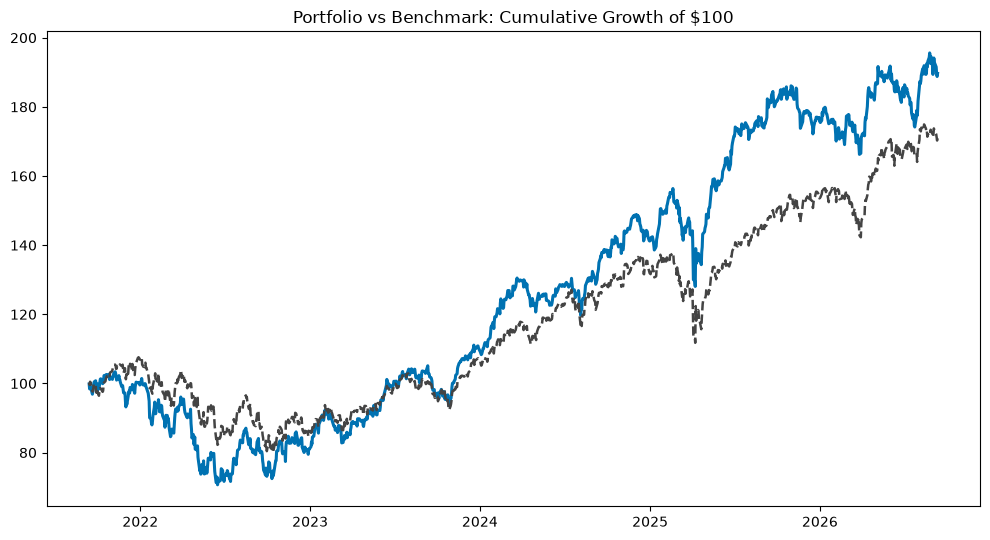

Portfolio total return: 89.7% | SPX total return: 71.7%
Portfolio annualized volatility: 18.8% | SPX annualized volatility: 17.0%


In [19]:
wide = fondo.pivot_table(index='Date', columns='Ticker', values='Daily_Return').sort_index()
portfolio_tickers = [t for t in ticker_order if t != 'SPX']
port_ret = wide[portfolio_tickers].mean(axis=1)
port_cum = (1 + port_ret.fillna(0)).cumprod() * 100
spx_cum = (1+ wide['SPX'].fillna(0)).cumprod() * 100

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(port_cum.index, port_cum.values, label='Equal-Weighted Portfolio (9 stocks)', color='#0072B2', linewidth=2.2)
ax.plot(spx_cum.index, spx_cum.values, label='S&P 500 (benchmark)', color='#444444', linewidth=1.8, linestyle='--')
ax.set_title('Portfolio vs Benchmark: Cumulative Growth of $100')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

print(f"Portfolio total return: {(port_cum.iloc[-1]/100 -1)*100:.1f}% | SPX total return: {(spx_cum.iloc[-1]/100 - 1)*100:.1f}%")
print(f"Portfolio annualized volatility: {port_ret.std()*np.sqrt(252)*100:.1f}% | SPX annualized volatility: {wide['SPX'].std()*np.sqrt(252)*100:.1f}%")


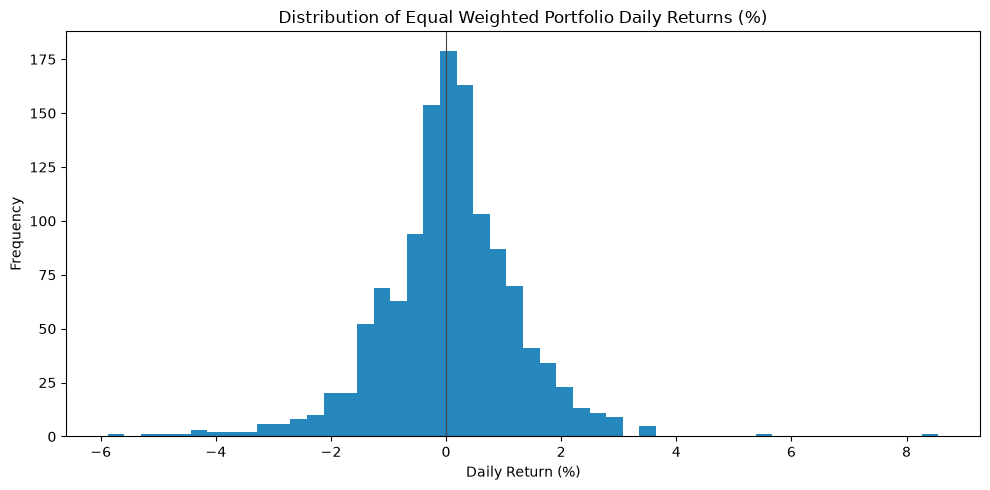

In [20]:
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(port_ret.dropna() * 100, bins=50, color='#0072B2', alpha=0.85)
ax.axvline(0, color='#444444', linewidth=0.8)
ax.set_title('Distribution of Equal Weighted Portfolio Daily Returns (%)')
ax.set_xlabel('Daily Return (%)'); ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

Interpretation:
